In [1]:
import jax.numpy as jnp
import numpy as np
import hj_reachability as hj
import matplotlib.pyplot as plt

In [18]:
class Pendulum(hj.ControlAndDisturbanceAffineDynamics):
    def __init__(self, g=9.81, l=1.0, m=1.0, u_max=2.0, d_max=0.0, control_mode="min", disturbance_mode="max"):
        self.g = g
        self.l = l
        self.m = m

        control_space = hj.sets.Box(lo=jnp.array([-u_max]), hi=jnp.array([u_max]))
        disturbance_space = hj.sets.Box(lo=jnp.array([-d_max]), hi=jnp.array([d_max]))

        super().__init__(control_mode=control_mode, disturbance_mode=disturbance_mode, control_space=control_space, disturbance_space=disturbance_space)

    def open_loop_dynamics(self, state, time):
        theta, omega = state[..., 0], state[..., 1]
        theta_dot = omega
        omega_dot = -(self.g/self.l)*jnp.sin(theta)
        return jnp.stack([theta_dot, omega_dot], axis=-1)

    def control_jacobian(self, state, time):
        coeff = 1.0/(self.m*self.l**2)
        zeros = jnp.zeros_like(state[..., 0])
        J_c = jnp.stack([jnp.stack([zeros], axis=-1), jnp.stack([coeff + 0.0*zeros], axis=-1)], axis=-2)
        return J_c

    def disturbance_jacobian(self, state, time):
        zeros = jnp.zeros_like(state[..., 0])
        J_d = jnp.stack([jnp.stack([zeros], axis=-1), jnp.stack([1.0+0.0*zeros], axis=-1)], axis=-2)
        return J_d

In [14]:
theta_min, theta_max = -np.pi, np.pi # boundary for the angle
omega_min, omega_max = -5.0, 5.0 # boundary for angular velocity

u_max = 0 # max control input
d_max = 0 # max disturbance

time = -1.0 # time of simulation
time_discretization = 201
grid_discretization = 201

times = np.linspace(0.0, time, time_discretization)
dynamics = Pendulum(u_max=u_max, d_max=d_max)
grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(hj.sets.Box(np.array([theta_min, omega_min]),np.array([theta_max, omega_max]),), shape=(grid_discretization, grid_discretization), periodic_dims=(0,))

theta_radius = 0.5
omega_radius = 0.5
theta = grid.states[..., 0]
omega = grid.states[..., 1]

In [15]:
values0 = (theta**2 / theta_radius**2) + (omega**2 / omega_radius**2) - 1.0

solver_settings = hj.SolverSettings.with_accuracy("high", hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)

value_function = hj.solve(solver_settings, dynamics, grid, times, values0)

100%|##################################|  1.0000/1.0 [00:01<00:00,  1.51s/sim_s]


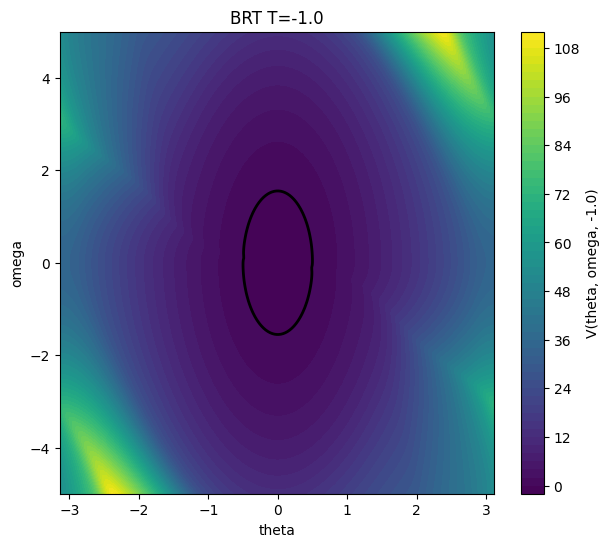

In [17]:
brt = np.array(value_function[-1]) # brs at -T

plt.figure(figsize=(7,6))
cf = plt.contourf(grid.coordinate_vectors[0], grid.coordinate_vectors[1], brt.T, levels=60)
plt.contour(grid.coordinate_vectors[0], grid.coordinate_vectors[1], brt.T, levels=[0], colors="black", linewidths=2)
plt.xlabel("theta")
plt.ylabel("omega")
plt.colorbar(cf, label=f"V(theta, omega, {time})")
plt.title(f"BRT T={time}")
plt.show()